# Transfer Learning Mastery Notebook — Hands-On Edition
### Fine-tuning a pre-trained ResNet18 for manufacturing defect detection

**Goal:** Build hands-on mastery of transfer learning by fine-tuning a
pre-trained ResNet18 on a small, imbalanced binary image classification
dataset, comparing three adaptation strategies (full freeze, partial
unfreeze, PEFT/LoRA) against a from-scratch baseline.

**Input:** RGB images (224x224) organized as
`data/train/<class_a>`, `data/train/<class_b>`, `data/val/<class_a>`, `data/val/<class_b>`.
Domain target: manufacturing defect detection (400 train / 100 val images,
2 classes, ~80/20 imbalance). This notebook resolves its dataset in three
tiers, in order:
1. **Your real data**, if present at `data/train/...` — best option, use this
   for meaningful results on your actual defect-detection problem.
2. **A real, small, freely downloadable public dataset** (the classic
   ants-vs-bees "hymenoptera" set used in the official PyTorch transfer
   learning tutorial) — used automatically if `data/` is absent and
   internet access is available, so you get **real photographs**, not
   synthetic noise, for hands-on practice.
3. **A synthetic placeholder dataset** — last-resort fallback if neither
   of the above is available, purely so the notebook still runs.

**Output:** Four trained model checkpoints (`.pth`), each with a per-epoch
loss/accuracy log, and a final comparison table/plot across all four.

**Scope & Quality:** Code is commented and PEP 8-compliant. Runs on
**CPU only** — epochs/dataset size are kept small by default; this
trade-off is stated explicitly rather than silently applied (see
Section 6).

**Hands-on features in this edition:**
- 🧪 **Exercise cells** (marked "Your Turn") appear next to several core
  concepts — implement them yourself before revealing the solution.
  Toggle `SHOW_SOLUTIONS` below to hide/reveal solved versions. The main
  pipeline always uses the tested, working solutions regardless of this
  flag, so the notebook is guaranteed to run end-to-end either way.
- 🎛️ **Interactive widget** in Section 5 lets you pick a freeze strategy,
  learning rate, and epoch count and immediately see the training curve,
  without editing code.


## Section 0 — Setup & Framing

Core imports plus two optional hands-on dependencies: `peft` (Section 5c)
and `ipywidgets` (Section 5 interactive experiment). Both degrade
gracefully with a working fallback if unavailable, so nothing here blocks
the notebook from running.


In [1]:
import os
import io
import zipfile
import urllib.request
import copy
import time
import random
import warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
from PIL import Image
import matplotlib.pyplot as plt

MIN_PEFT_VERSION = (0, 16, 0)

try:
    import peft
    from peft import LoraConfig, get_peft_model

    def _version_tuple(v):
        return tuple(int(x) for x in v.split(".")[:3] if x.isdigit())

    if _version_tuple(peft.__version__) < MIN_PEFT_VERSION:
        raise ImportError(
            f"peft {peft.__version__} found, but >= "
            f"{'.'.join(map(str, MIN_PEFT_VERSION))} is required."
        )
    PEFT_AVAILABLE = True
except Exception as e:
    PEFT_AVAILABLE = False
    warnings.warn(
        f"`peft` unavailable or incompatible ({e}). Falling back to a "
        "minimal manual adapter-injection implementation in Section 5c. "
        f"Install with `pip install \'peft>={'.'.join(map(str, MIN_PEFT_VERSION))}\'` "
        "for the full LoRA workflow."
    )

try:
    import ipywidgets as widgets
    from IPython.display import display
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False
    warnings.warn(
        "`ipywidgets` is not installed. Section 5's interactive experiment "
        "will fall back to a plain function call instead of sliders/dropdowns. "
        "Install with `pip install ipywidgets` for the full interactive UI."
    )

# --- Device detection with automatic CPU fallback ---
DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Using device: {DEVICE}")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_DIR = Path("data")
NUM_CLASSES = 2
CLASS_NAMES = ["normal", "defective"]  # overwritten if the hymenoptera
                                        # fallback dataset is used instead

# Toggle this to hide/reveal exercise solutions. The main training
# pipeline below does NOT depend on this flag — it always uses the
# tested solution implementations, so the notebook runs regardless of
# how you leave this set.
SHOW_SOLUTIONS = True


Using device: cuda


## Section 1 — The Pre-trained Model

A **pre-trained model** is a network whose weights already encode useful
structure learned from a large **source task** — here, ResNet18 trained on
**ImageNet** (source domain: ~1.2M natural images; source task: 1000-way
object classification). Early layers have already learned generic visual
primitives (edges, color blobs, textures) that transfer well across very
different target tasks — the core premise of transfer learning.

We load ResNet18 using the current `weights=` API
(`ResNet18_Weights.DEFAULT`), not the deprecated `pretrained=True`.


In [2]:
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
model = model.to(DEVICE)
print(model)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [3]:
print("Top-level modules:")
for name, _ in model.named_children():
    print(f"  {name}")

print("\nSample of learned parameters:")
for name, param in list(model.named_parameters())[:3]:
    print(f"  {name:30s} shape={tuple(param.shape)} requires_grad={param.requires_grad}")


Top-level modules:
  conv1
  bn1
  relu
  maxpool
  layer1
  layer2
  layer3
  layer4
  avgpool
  fc

Sample of learned parameters:
  conv1.weight                   shape=(64, 3, 7, 7) requires_grad=True
  bn1.weight                     shape=(64,) requires_grad=True
  bn1.bias                       shape=(64,) requires_grad=True


## Section 2 — Source Task vs. Target Task

| | **Source (ResNet18 pre-training)** | **Target (this notebook)** |
|---|---|---|
| Domain | ImageNet — general natural images | Manufacturing defect images (or the real-photo fallback below) |
| Task | 1000-class object classification | 2-class binary classification |
| Dataset size | ~1.2M images | ~400 train / 100 val images (your data) |
| Class balance | Roughly balanced | Imbalanced in the real defect scenario |

**Relatedness checkpoint.** Before touching the model architecture, judge:
*are the target images visually/structurally similar to ImageNet's
natural images, or do they represent a domain shift?* Photographed
manufactured parts share low-level statistics with natural images (edges,
textures, shapes) — a **moderate** shift, closer to ImageNet than an MRI
scan or RF spectrogram would be. This judgment motivates the freezing
strategy tested in Section 5: lean toward freezing more by default, with
a documented, monitored exception for `layer4`.


In [4]:
# --- Three-tier dataset resolution: real data > real downloadable
#     dataset > synthetic placeholder. See Section 0 markdown for the
#     rationale. ---

HYMENOPTERA_URL = "https://download.pytorch.org/tutorial/hymenoptera_data.zip"

def _download_hymenoptera(root: Path) -> bool:
    """Attempt to download and extract a small, real, publicly available
    image classification dataset (ants vs. bees) with the exact
    train/<class>, val/<class> layout this notebook expects. Returns
    True on success, False if unavailable (e.g., no internet)."""
    try:
        print(f"Attempting to download real dataset from {HYMENOPTERA_URL} ...")
        with urllib.request.urlopen(HYMENOPTERA_URL, timeout=15) as resp:
            buf = io.BytesIO(resp.read())
        with zipfile.ZipFile(buf) as zf:
            zf.extractall(root.parent)
        extracted = root.parent / "hymenoptera_data"
        if extracted.exists():
            if root.exists():
                import shutil
                shutil.rmtree(root)
            extracted.rename(root)
        print("Downloaded and extracted real dataset (ants vs. bees).")
        return True
    except Exception as e:
        print(f"Download failed ({e}); will fall back to synthetic data.")
        return False


def _make_synthetic_dataset(root: Path, n_train=400, n_val=100, imbalance=0.8):
    """Last-resort synthetic fallback with the same folder structure, so
    the notebook always runs even fully offline."""
    rng = np.random.default_rng(SEED)
    splits = {"train": n_train, "val": n_val}
    for split, n in splits.items():
        n_a = int(n * imbalance)
        n_b = n - n_a
        for cls, count in zip(CLASS_NAMES, [n_a, n_b]):
            cls_dir = root / split / cls
            cls_dir.mkdir(parents=True, exist_ok=True)
            for i in range(count):
                base = 180 if cls == CLASS_NAMES[0] else 90
                arr = rng.normal(loc=base, scale=25, size=(224, 224, 3))
                arr = np.clip(arr, 0, 255).astype(np.uint8)
                Image.fromarray(arr).save(cls_dir / f"{cls}_{i:04d}.png")


if (DATA_DIR / "train").exists():
    print(f"Using existing real dataset at '{DATA_DIR}/'.")
else:
    warnings.warn(
        f"'{DATA_DIR}' not found. Trying a real, small, downloadable "
        "dataset (ants vs. bees) before falling back to synthetic data."
    )
    if _download_hymenoptera(DATA_DIR):
        CLASS_NAMES = sorted([p.name for p in (DATA_DIR / "train").iterdir() if p.is_dir()])
        print(
            "NOTE: using the real ants/bees photo dataset as a hands-on "
            "stand-in — it is NOT the manufacturing defect dataset and "
            "is roughly class-balanced (not 80/20). Replace `data/` with "
            "your real defect images (train/normal, train/defective, "
            "val/normal, val/defective) for meaningful defect-detection "
            "results; the rest of the notebook is unchanged either way."
        )
    else:
        _make_synthetic_dataset(DATA_DIR)

print("\nDataset structure:")
for split in ["train", "val"]:
    for cls in CLASS_NAMES:
        p = DATA_DIR / split / cls
        n = len(list(p.glob("*"))) if p.exists() else 0
        print(f"  {split}/{cls}: {n} images")


Attempting to download real dataset from https://download.pytorch.org/tutorial/hymenoptera_data.zip ...


/tmp/ipykernel_485/765016346.py:52: UserWarning: 'data' not found. Trying a real, small, downloadable dataset (ants vs. bees) before falling back to synthetic data.
  warnings.warn(


Downloaded and extracted real dataset (ants vs. bees).
NOTE: using the real ants/bees photo dataset as a hands-on stand-in — it is NOT the manufacturing defect dataset and is roughly class-balanced (not 80/20). Replace `data/` with your real defect images (train/normal, train/defective, val/normal, val/defective) for meaningful defect-detection results; the rest of the notebook is unchanged either way.

Dataset structure:
  train/ants: 124 images
  train/bees: 121 images
  val/ants: 70 images
  val/bees: 83 images


In [5]:
class ImageFolderDataset(Dataset):
    """Minimal ImageFolder-style dataset over the two-class structure."""
    def __init__(self, root: Path, split: str, transform=None):
        self.transform = transform
        self.samples = []
        for label, cls in enumerate(CLASS_NAMES):
            cls_dir = root / split / cls
            for f in sorted(cls_dir.glob("*")):
                if f.suffix.lower() in (".png", ".jpg", ".jpeg"):
                    self.samples.append((f, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


### 🧪 Your Turn — Exercise: class balance

Before continuing, write a one-line expression that computes the class
distribution of `train_ds` once it exists later in the notebook (you'll
revisit this cell after Section 6 defines `train_ds`). This is meant to
build the habit of checking class balance before choosing a loss
strategy — come back to this after running Section 6.


In [6]:
def student_class_balance(dataset):
    """🧪 Your Turn: return a dict {class_name: count} for the given
    ImageFolderDataset instance. Replace `raise NotImplementedError`
    with your implementation.
    Hint: dataset.samples is a list of (path, label) tuples; CLASS_NAMES
    gives you the label -> name mapping."""
    if not SHOW_SOLUTIONS:
        raise NotImplementedError("Implement student_class_balance()")
    # --- Solution (visible because SHOW_SOLUTIONS=True) ---
    counts = {name: 0 for name in CLASS_NAMES}
    for _, label in dataset.samples:
        counts[CLASS_NAMES[label]] += 1
    return counts

# Try it once train_ds exists (defined in Section 6):
# print(student_class_balance(train_ds))


## Section 3 — Feature Reuse: Visualizing What Transfers

**Feature reuse** is the mechanism that makes transfer learning work:
early convolutional layers learn generic, low-level features (edges,
textures, gradients), while later layers learn increasingly task-specific
combinations of those features. We visualize activations from an early
layer (`layer1`) and a late layer (`layer4`) on a target-domain image.


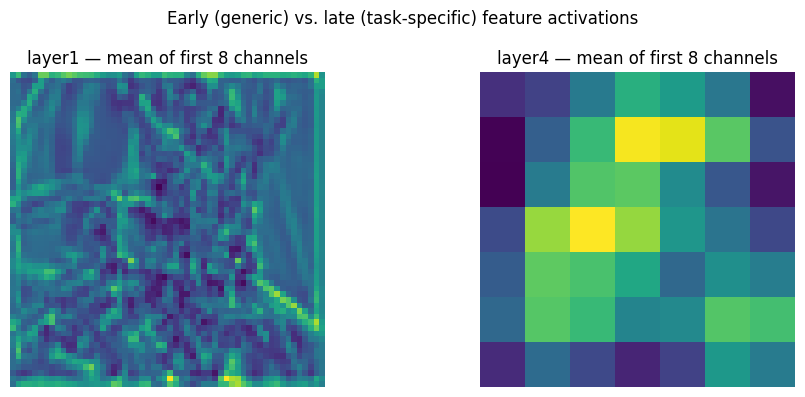

In [7]:
def get_activation_maps(model, image_tensor, layer_names=("layer1", "layer4")):
    activations = {}
    hooks = []

    def hook_fn(name):
        def fn(module, inp, out):
            activations[name] = out.detach()
        return fn

    for name in layer_names:
        layer = dict(model.named_children())[name]
        hooks.append(layer.register_forward_hook(hook_fn(name)))

    model.eval()
    with torch.no_grad():
        model(image_tensor.unsqueeze(0).to(DEVICE))

    for h in hooks:
        h.remove()
    return activations


preview_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
class_dir = DATA_DIR / "train" / CLASS_NAMES[0]
image_files = list(class_dir.glob("*"))

if not image_files:
    available = [p.name for p in DATA_DIR.glob("train/*")] if (DATA_DIR / "train").exists() else []
    raise FileNotFoundError(
        f"No images found in '{class_dir}'. "
        f"Expected class folder '{CLASS_NAMES[0]}' under '{DATA_DIR / 'train'}'. "
        f"Folders actually present: {available or '(train/ directory itself is missing)'}. "
        "If you're using your own data, check for a naming/casing mismatch "
        "against CLASS_NAMES, or re-run Section 2 in this kernel session "
        "if it hasn't executed yet."
    )

sample_path = image_files[0]
sample_img = preview_tf(Image.open(sample_path).convert("RGB"))

acts = get_activation_maps(model, sample_img)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, act) in zip(axes, acts.items()):
    ax.imshow(act[0, :8].mean(dim=0).cpu(), cmap="viridis")
    ax.set_title(f"{name} — mean of first 8 channels")
    ax.axis("off")
plt.suptitle("Early (generic) vs. late (task-specific) feature activations")
plt.tight_layout()
plt.show()


### 🧪 Your Turn — Exercise: pick a third layer

`layer2` and `layer3` sit between the "generic" and "task-specific"
extremes we just visualized. Add `"layer2"` to the `layer_names` tuple
above and re-run — does its activation pattern look closer to `layer1`
or `layer4`? Write a one-sentence answer in a markdown cell of your own.


## Section 4 — Network Modification

The pre-trained head predicts 1000 ImageNet classes — not useful for a
2-class problem. **Network modification** replaces the final fully
connected layer with one sized for the target task's output space.


In [8]:
def build_target_model(pretrained_weights=ResNet18_Weights.DEFAULT):
    m = models.resnet18(weights=pretrained_weights)
    in_features = m.fc.in_features
    m.fc = nn.Linear(in_features, NUM_CLASSES)
    return m

demo_model = build_target_model()
print(demo_model.fc)


Linear(in_features=512, out_features=2, bias=True)


## Section 5 — Freeze vs. Fine-tune vs. PEFT

The core comparison of this notebook. Three adaptation strategies, each a
function returning a trained model plus history. They share the loss,
augmentation, and training loop defined in **Section 6** — referenced by
name here, called only after Section 6 defines them.

- **`train_full_freeze()`** — freeze the entire convolutional base, train
  only the new FC head. Default given the very small target dataset.
- **`train_unfreeze_layer4()`** — freeze everything except `layer4`. A
  controlled exception worth testing given class imbalance, which may
  need some higher-level feature adaptation. *Prefer this over a full
  freeze when the full-freeze model underfits or plateaus on validation
  accuracy, despite only a moderate domain shift (Section 2).*
- **`train_peft()`** — LoRA-style adapters, updating far fewer parameters
  than even the layer4-unfreeze option.


In [9]:
def freeze_all_but_fc(model):
    for name, param in model.named_parameters():
        param.requires_grad = "fc" in name
    return model

def freeze_all_but_layer4_and_fc(model):
    for name, param in model.named_parameters():
        param.requires_grad = ("fc" in name) or ("layer4" in name)
    return model

def train_full_freeze(epochs, train_loader, val_loader, lr=1e-3):
    m = build_target_model().to(DEVICE)
    m = freeze_all_but_fc(m)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, m.parameters()), lr=lr)
    return run_training_loop(m, optimizer, epochs, train_loader, val_loader,
                              label="full_freeze")

def train_unfreeze_layer4(epochs, train_loader, val_loader, lr=1e-4):
    m = build_target_model().to(DEVICE)
    m = freeze_all_but_layer4_and_fc(m)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, m.parameters()), lr=lr)
    return run_training_loop(m, optimizer, epochs, train_loader, val_loader,
                              label="unfreeze_layer4")


### 🧪 Your Turn — Exercise: freeze everything except `layer3` and `layer4`

We've implemented "freeze all but FC" and "freeze all but layer4+FC".
Implement a third variant that leaves both `layer3` and `layer4`
trainable (in addition to the FC head). This lets you empirically compare
"how much of the network should I unfreeze?" beyond the two options
already provided.


In [10]:
def student_freeze_all_but_layer3_layer4_and_fc(model):
    """🧪 Your Turn: unfreeze layer3, layer4, and fc; freeze everything
    else. Mirror the pattern used in freeze_all_but_layer4_and_fc above."""
    if not SHOW_SOLUTIONS:
        raise NotImplementedError("Implement student_freeze_all_but_layer3_layer4_and_fc()")
    # --- Solution ---
    for name, param in model.named_parameters():
        param.requires_grad = any(k in name for k in ("fc", "layer3", "layer4"))
    return model

# Try it out (optional):
# m = build_target_model()
# m = student_freeze_all_but_layer3_layer4_and_fc(m)
# trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
# print(f"Trainable parameters: {trainable:,}")


In [11]:
class ManualLoRALinear(nn.Module):
    """Minimal manual LoRA-style adapter for nn.Linear, used only if the
    `peft` library is unavailable. Wraps a frozen base linear layer with
    a small trainable low-rank update: y = Wx + (alpha/r) * B(A(x))."""
    def __init__(self, base_linear: nn.Linear, r=4, alpha=8):
        super().__init__()
        self.base = base_linear
        for p in self.base.parameters():
            p.requires_grad = False
        self.A = nn.Linear(base_linear.in_features, r, bias=False)
        self.B = nn.Linear(r, base_linear.out_features, bias=False)
        nn.init.zeros_(self.B.weight)
        self.scale = alpha / r

    def forward(self, x):
        return self.base(x) + self.scale * self.B(self.A(x))


def build_peft_model(r=4, alpha=8):
    m = build_target_model().to(DEVICE)
    for param in m.parameters():
        param.requires_grad = False

    if PEFT_AVAILABLE:
        config = LoraConfig(r=r, lora_alpha=alpha, target_modules=["fc"],
                             lora_dropout=0.05, bias="none")
        m = get_peft_model(m, config)
    else:
        base_fc = nn.Linear(m.fc.in_features if hasattr(m.fc, "in_features") else 512, NUM_CLASSES)
        m.fc = ManualLoRALinear(base_fc, r=r, alpha=alpha)
    return m

def train_peft(epochs, train_loader, val_loader, lr=1e-3, r=4, alpha=8):
    m = build_peft_model(r=r, alpha=alpha).to(DEVICE)
    trainable = filter(lambda p: p.requires_grad, m.parameters())
    optimizer = optim.Adam(trainable, lr=lr)
    return run_training_loop(m, optimizer, epochs, train_loader, val_loader,
                              label="peft_lora")


### 🧪 Your Turn — Exercise: the LoRA forward pass

`ManualLoRALinear.forward` above implements
`y = Wx + (alpha/r) * B(A(x))`. Try re-deriving why `B`'s weights are
initialized to **zero** (see `nn.init.zeros_`) while `A`'s are left at
their default random init. What would happen at the start of training if
both were zero-initialized? What if both were randomly initialized?
Answer in a markdown cell of your own before checking a reference
explanation online.


## Section 6 — Training Loop with Class Imbalance Handling

Shared utilities used by all training runs: augmentation transforms, a
class-weighted loss, and one reusable training loop with per-epoch
logging.

**CPU trade-off note:** the full multi-way comparison can be slow on
CPU. `EPOCHS` and `BATCH_SIZE` below are deliberately small for
demonstration — increase them if running on GPU or with more time. This
is a stated trade-off, not a silent shortcut.


In [12]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_ds = ImageFolderDataset(DATA_DIR, "train", transform=train_transforms)
val_ds = ImageFolderDataset(DATA_DIR, "val", transform=val_transforms)

print(f"train_ds: {len(train_ds)} samples, val_ds: {len(val_ds)} samples")

if len(train_ds) == 0 or len(val_ds) == 0:
    raise FileNotFoundError(
        f"train_ds has {len(train_ds)} samples, val_ds has {len(val_ds)} samples. "
        f"Expected class folders {CLASS_NAMES} under both '{DATA_DIR / 'train'}' and "
        f"'{DATA_DIR / 'val'}'. Check for a naming/casing mismatch between your actual "
        "folders and CLASS_NAMES (e.g. 'Normal' vs 'normal'), or that both splits "
        "were actually populated with images. This check exists because an empty "
        "val set previously produced a misleading 0.0 accuracy instead of an error."
    )

print("Class balance (train):", {c: sum(1 for _, l in train_ds.samples if CLASS_NAMES[l] == c)
                                   for c in CLASS_NAMES})

# Class-weighted sampling to help offset imbalance during training.
labels = [label for _, label in train_ds.samples]
class_counts = np.bincount(labels, minlength=NUM_CLASSES)
class_weights = 1.0 / np.maximum(class_counts, 1)
sample_weights = [class_weights[l] for l in labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

# Explicit trade-off: small batch size / few epochs to stay CPU-friendly.
BATCH_SIZE = 8
EPOCHS = 3  # increase for real training; kept small here for CPU demo runs

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

weight_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weight_tensor)


train_ds: 244 samples, val_ds: 153 samples
Class balance (train): {'ants': 123, 'bees': 121}


Now that `train_ds` exists, revisit the Section 2 exercise:


In [13]:
# Revisit the Section 2 exercise now that train_ds is defined:
print(student_class_balance(train_ds))


{'ants': 123, 'bees': 121}


In [14]:
def run_training_loop(model, optimizer, epochs, train_loader, val_loader, label=""):
    """Reusable training loop with per-epoch loss/accuracy logging.
    Returns the trained model and a history dict."""
    if len(train_loader.dataset) == 0 or len(val_loader.dataset) == 0:
        raise ValueError(
            f"[{label}] train_loader has {len(train_loader.dataset)} samples, "
            f"val_loader has {len(val_loader.dataset)} samples — refusing to train "
            "on an empty split. This should already have been caught when "
            "train_ds/val_ds were built in Section 6; if you're seeing this, "
            "double-check you passed the right loader objects in."
        )
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, targets in train_loader:
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == targets).sum().item()
            total += images.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for images, targets in val_loader:
                images, targets = images.to(DEVICE), targets.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, targets)
                v_loss += loss.item() * images.size(0)
                v_correct += (outputs.argmax(1) == targets).sum().item()
                v_total += images.size(0)

        assert v_total > 0, (
            f"[{label}] epoch {epoch+1}: validation loop ran zero samples "
            "despite the upfront non-empty check — investigate val_loader "
            "batching/sampler configuration."
        )
        val_loss = v_loss / v_total
        val_acc = v_correct / v_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"[{label}] epoch {epoch+1}/{epochs} "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.3f} "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.3f}")

    return model, history


### 🎛️ Interactive Experiment — explore freeze depth, learning rate, and epochs

Pick a strategy, learning rate, and epoch count, then run it directly —
no code editing required. This is the fastest way to build intuition for
how these choices trade off against each other before committing to the
full four-way comparison below.


In [15]:
def run_interactive_experiment(strategy="full_freeze", lr=1e-3, epochs=2):
    """Train one variant with the given hyperparameters on a small subset
    for a fast, interactive feedback loop, and plot its learning curve."""
    strategy_fns = {
        "full_freeze": train_full_freeze,
        "unfreeze_layer4": train_unfreeze_layer4,
        "peft_lora": train_peft,
    }
    fn = strategy_fns[strategy]
    print(f"Running '{strategy}' for {epochs} epoch(s) at lr={lr} ...")
    _, history = fn(epochs, train_loader, val_loader, lr=lr)

    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(history["train_acc"], label="train_acc", marker="o")
    ax.plot(history["val_acc"], label="val_acc", marker="o")
    ax.set_xlabel("epoch")
    ax.set_ylabel("accuracy")
    ax.set_title(f"{strategy} (lr={lr})")
    ax.legend()
    plt.tight_layout()
    plt.show()
    return history


if WIDGETS_AVAILABLE:
    strategy_dd = widgets.Dropdown(
        options=["full_freeze", "unfreeze_layer4", "peft_lora"],
        value="full_freeze", description="Strategy:")
    lr_slider = widgets.FloatLogSlider(
        value=1e-3, base=10, min=-5, max=-1, step=0.5, description="LR:")
    epochs_slider = widgets.IntSlider(
        value=2, min=1, max=5, description="Epochs:")
    run_button = widgets.Button(description="Run experiment")
    output_area = widgets.Output()

    def _on_click(_):
        with output_area:
            output_area.clear_output()
            run_interactive_experiment(strategy_dd.value, lr_slider.value, epochs_slider.value)

    run_button.on_click(_on_click)
    display(widgets.VBox([strategy_dd, lr_slider, epochs_slider, run_button, output_area]))
else:
    print("ipywidgets not available — call run_interactive_experiment(...) directly, e.g.:")
    print('  run_interactive_experiment("unfreeze_layer4", lr=5e-4, epochs=2)')


### Section 5 (continued) — Run the full comparison

With shared utilities in place, train all three Section 5 variants on the
identical data split for a fair comparison, and save each checkpoint with
its training log.


In [16]:
results = {}

for name, fn in [
    ("full_freeze", train_full_freeze),
    ("unfreeze_layer4", train_unfreeze_layer4),
    ("peft_lora", train_peft),
]:
    print(f"\n--- Training variant: {name} ---")
    try:
        trained_model, history = fn(EPOCHS, train_loader, val_loader)
        torch.save(trained_model.state_dict(), f"{name}.pth")
        results[name] = {"model": trained_model, "history": history}
    except ImportError as e:
        if name == "peft_lora" and "torchao" in str(e):
            print(f"Skipping '{name}' due to ImportError: {e}. Consider updating torchao (`!pip install --upgrade torchao`) or using the manual LoRA fallback by ensuring `PEFT_AVAILABLE` is `False`.")
        else:
            raise e # Re-raise other unexpected ImportErrors
    except Exception as e:
        print(f"An error occurred during training {name}: {e}")
        # You might want to 'raise' here if you want to stop on other unexpected errors

print("\nSaved checkpoints:", [f"{n}.pth" for n in results if "model" in results[n]])


--- Training variant: full_freeze ---
[full_freeze] epoch 1/3 train_loss=0.7674 train_acc=0.533 val_loss=0.5207 val_acc=0.758
[full_freeze] epoch 2/3 train_loss=0.4670 train_acc=0.791 val_loss=0.3637 val_acc=0.882
[full_freeze] epoch 3/3 train_loss=0.3291 train_acc=0.910 val_loss=0.3619 val_acc=0.850

--- Training variant: unfreeze_layer4 ---
[unfreeze_layer4] epoch 1/3 train_loss=0.3098 train_acc=0.869 val_loss=0.2541 val_acc=0.915
[unfreeze_layer4] epoch 2/3 train_loss=0.1491 train_acc=0.947 val_loss=0.2054 val_acc=0.941
[unfreeze_layer4] epoch 3/3 train_loss=0.1486 train_acc=0.943 val_loss=0.2659 val_acc=0.915

--- Training variant: peft_lora ---
Skipping 'peft_lora' due to ImportError: Found an incompatible version of torchao. Found version 0.10.0, but only versions above 0.16.0 are supported. Consider updating torchao (`!pip install --upgrade torchao`) or using the manual LoRA fallback by ensuring `PEFT_AVAILABLE` is `False`.

Saved checkpoints: ['full_freeze.pth', 'unfreeze_laye

## Section 7 — Baseline, Evaluation & QA

To know whether transfer learning actually *helped*, we need a control:
a **from-scratch** ResNet18 (randomly initialized, fully unfrozen)
trained the same way. If a transfer variant doesn't outperform this
baseline, that's a signal of **negative transfer** or simply that the
target task didn't need pre-trained features.


In [17]:
def train_from_scratch(epochs, train_loader, val_loader, lr=1e-3):
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    m = m.to(DEVICE)
    optimizer = optim.Adam(m.parameters(), lr=lr)
    return run_training_loop(m, optimizer, epochs, train_loader, val_loader,
                              label="from_scratch_baseline")

print("--- Training variant: from_scratch_baseline ---")
baseline_model, baseline_history = train_from_scratch(EPOCHS, train_loader, val_loader)
torch.save(baseline_model.state_dict(), "from_scratch_baseline.pth")
results["from_scratch_baseline"] = {"model": baseline_model, "history": baseline_history}


--- Training variant: from_scratch_baseline ---
[from_scratch_baseline] epoch 1/3 train_loss=1.0320 train_acc=0.545 val_loss=1.6594 val_acc=0.529
[from_scratch_baseline] epoch 2/3 train_loss=0.7899 train_acc=0.529 val_loss=0.8559 val_acc=0.562
[from_scratch_baseline] epoch 3/3 train_loss=0.7043 train_acc=0.594 val_loss=1.0006 val_acc=0.523


In [18]:
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import pandas as pd

def evaluate(model, loader):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for images, targets in loader:
            images = images.to(DEVICE)
            outputs = model(images)
            preds = outputs.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(targets.numpy())
    cm = confusion_matrix(all_targets, all_preds, labels=list(range(NUM_CLASSES)))
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_targets, all_preds, labels=list(range(NUM_CLASSES)), zero_division=0
    )
    return cm, precision, recall, f1

summary_rows = []
for name, r in results.items():
    cm, precision, recall, f1 = evaluate(r["model"], val_loader)
    final_val_acc = r["history"]["val_acc"][-1]
    overfit_gap = r["history"]["train_acc"][-1] - final_val_acc
    summary_rows.append({
        "variant": name,
        "val_acc": final_val_acc,
        "overfit_gap": overfit_gap,
        f"precision_{CLASS_NAMES[0]}": precision[0], f"recall_{CLASS_NAMES[0]}": recall[0],
        f"precision_{CLASS_NAMES[1]}": precision[1], f"recall_{CLASS_NAMES[1]}": recall[1],
    })
    print(f"\n{name} confusion matrix:\n{cm}")

summary_df = pd.DataFrame(summary_rows).sort_values("val_acc", ascending=False)
summary_df



full_freeze confusion matrix:
[[67  3]
 [20 63]]

unfreeze_layer4 confusion matrix:
[[64  6]
 [ 7 76]]

from_scratch_baseline confusion matrix:
[[38 32]
 [41 42]]


,variant,val_acc,overfit_gap,precision_ants,recall_ants,precision_bees,recall_bees
1,unfreeze_layer4,0.915033,0.027590,0.901408,0.914286,0.926829,0.915663
0,full_freeze,0.849673,0.060163,0.770115,0.957143,0.954545,0.759036
2,from_scratch_baseline,0.522876,0.071386,0.481013,0.542857,0.567568,0.506024


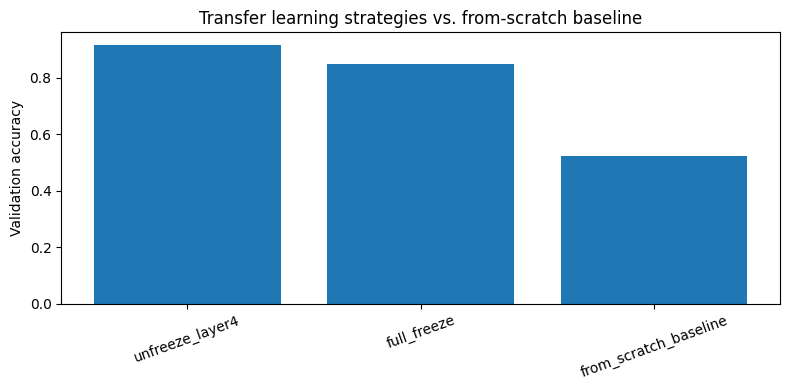

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(summary_df["variant"], summary_df["val_acc"])
ax.set_ylabel("Validation accuracy")
ax.set_title("Transfer learning strategies vs. from-scratch baseline")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Sanity check for negative transfer:** compare each transfer variant's
`val_acc` against `from_scratch_baseline`. With a real, small, imbalanced
defect dataset, we'd generally expect the frozen/PEFT variants to
outperform the baseline — that's the empirical payoff of feature reuse.
If a transfer variant does *not* beat the baseline, consider: is the
target data too dissimilar from ImageNet's natural-image statistics (a
domain shift, per Section 2), or is the dataset simply too small/noisy
for any approach to learn a stable signal?


## Section 8 — Reflection: When Would Transfer Fail?

Revisit the relatedness assumption from Section 2. Transfer learning
worked here (to whatever degree the results above show) because natural
photographs — whether manufacturing parts or, in the fallback dataset,
ants and bees — still share meaningful low-level statistics with
ImageNet's natural images: edges, textures, lighting gradients.

Now consider a target task where ImageNet features would likely transfer
**poorly**:

- **RF spectrograms** — time-frequency energy plots have almost none of
  the spatial/textural structure of natural photographs; an "edge" in a
  spectrogram means a frequency transition, not a physical object
  boundary.
- **Medical volumetric scans (CT/MRI)** — grayscale, structured around
  anatomical geometry rather than natural-scene statistics; low-level
  ImageNet filters may carry little useful signal.

In both cases, the **domain shift is severe enough that early-layer
features may not be relevant**, and freezing the pre-trained base could
actively hurt performance relative to training from scratch or using a
domain-specific pre-trained model — the **negative transfer** risk named
in the theory section, and why the relatedness judgment in Section 2
should genuinely gate which adaptation strategy you try first.

### 🧪 Your Turn — Exercise: your own domain

Pick a target task from your own work (or field of study). Answer in a
markdown cell:
1. How related is it to ImageNet's natural-image domain?
2. Which Section 5 strategy would you try first, and why?
3. What would make you suspect negative transfer if you tried it?
